In [ ]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureEmodb.csv')

In [ ]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [3]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,emo,speaker
0,-290.069550,120.892410,-44.022133,59.493820,-25.234184,24.166288,-20.102554,-3.104467,-3.912210,-8.433292,...,56.398769,0.009679,0.012519,-0.031646,0.024728,0.007912,0.001966,0,6,3
1,-274.512543,137.867325,-33.016861,49.305836,-7.529972,15.471715,-6.811347,-7.069037,-8.804790,-1.528063,...,53.806400,-0.001984,0.006133,-0.084608,0.109369,-0.025859,-0.003522,0,3,3
2,-225.866470,94.075874,-72.961555,41.311485,-27.577299,12.030844,-14.943604,-8.053857,-11.431667,-10.043902,...,54.852081,0.001015,-0.006297,-0.033966,-0.076824,0.011315,-0.001692,0,1,3
3,-273.849060,98.794968,-36.564865,36.316208,-22.404598,18.368185,-12.455775,-1.077722,-12.487121,-17.107168,...,58.313221,0.039030,-0.017753,-0.081100,-0.049775,0.015536,-0.007109,0,6,3
4,-252.887863,149.398911,-24.717367,45.297226,-0.930259,5.930630,0.473345,-0.681704,-12.864426,-9.714954,...,51.336941,0.008184,-0.018455,-0.020061,-0.058433,0.009487,0.034003,0,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264,1,2,16
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948,1,7,16
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342,1,7,16
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701,1,1,16


In [4]:
import joblib

# Load the saved scaler
scaler = joblib.load("../scaler.pkl")

# Load the saved model
gender_model = tf.keras.models.load_model("../gender_classification_model.h5")

W0000 00:00:1761900753.702890 2635343 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
X_gender = data.iloc[:, :193].values
X_scaled = scaler.transform(X_gender)
gender_predictions = gender_model.predict(X_scaled)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [6]:
print(gender_predictions)

[[4.5035286e-03]
 [6.3186768e-04]
 [6.3902155e-02]
 [9.7367173e-04]
 [3.5927637e-04]
 [4.1427597e-04]
 [2.2512616e-04]
 [8.7063039e-05]
 [1.4214022e-01]
 [5.2732592e-03]
 [3.9477255e-03]
 [6.3394487e-04]
 [3.3596822e-03]
 [6.4636220e-04]
 [3.5628288e-03]
 [4.1314136e-04]
 [1.4828285e-03]
 [1.0088192e-03]
 [1.4837601e-03]
 [8.3817112e-01]
 [4.9589720e-04]
 [8.7612588e-03]
 [9.6683035e-04]
 [1.8841011e-04]
 [2.5844909e-04]
 [1.0775754e-04]
 [1.3896544e-03]
 [8.3173887e-04]
 [1.9456262e-03]
 [3.6225046e-04]
 [1.0010075e-03]
 [1.2998246e-02]
 [2.4798091e-03]
 [5.9699983e-04]
 [2.6846221e-03]
 [1.9824847e-04]
 [1.2996431e-03]
 [1.6774883e-03]
 [1.4106421e-03]
 [1.9208312e-03]
 [6.9094729e-04]
 [2.9094936e-03]
 [1.7472634e-04]
 [1.7159596e-02]
 [1.6623145e-03]
 [6.5588527e-03]
 [2.9166941e-02]
 [8.3075669e-05]
 [6.9666803e-01]
 [9.9879277e-01]
 [9.9971902e-01]
 [9.9914515e-01]
 [9.9036449e-01]
 [9.9874341e-01]
 [9.1266567e-01]
 [9.9998790e-01]
 [9.9450457e-01]
 [9.9892360e-01]
 [9.9667352e-0

In [7]:
male_rows = gender_predictions.flatten() >= 0.5  # 0 for Male, 1 for Female

df = data[male_rows]

print(f"Filtered dataset contains {df.shape[0]} female samples.")

Filtered dataset contains 305 female samples.


In [8]:
df.shape

(305, 196)

In [9]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,emo,speaker
19,-252.926743,97.129494,-62.079552,38.996372,-32.850922,11.289834,-21.996538,-11.891141,-13.001657,-19.354004,...,56.454013,-0.004030,-0.003963,-0.017737,0.007128,0.012398,-0.007039,0,1,3
48,-253.717316,87.844467,-61.708538,43.870251,-29.599110,1.335139,-24.585815,-3.843721,-14.385295,-24.504915,...,56.501779,0.043960,0.006167,-0.071178,-0.028238,-0.005400,0.003242,0,1,3
49,-242.296738,100.131287,-49.905891,39.019207,-28.569174,28.434782,-22.502106,-8.388103,-1.577434,-16.187185,...,56.029853,0.016974,0.017489,0.021310,-0.077259,-0.011524,-0.013297,1,5,8
50,-185.100357,102.095390,-32.449959,48.499172,-18.903458,17.655661,-11.422845,3.079878,-1.342817,-5.473735,...,56.943466,-0.006739,0.013350,0.045375,0.115081,0.011807,0.032250,1,6,8
51,-296.696777,111.588104,-15.979291,30.510899,-11.087157,21.032894,-8.265782,-8.720767,-4.711420,-11.372763,...,55.685641,-0.081280,0.044741,0.183663,-0.005616,-0.015490,0.079741,1,2,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264,1,2,16
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948,1,7,16
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342,1,7,16
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701,1,1,16


In [10]:
data.iloc[:,-3] == 1 

0      False
1      False
2      False
3      False
4      False
       ...  
530     True
531     True
532     True
533     True
534     True
Name: gender, Length: 535, dtype: bool

In [11]:
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [12]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
19,-252.926743,97.129494,-62.079552,38.996372,-32.850922,11.289834,-21.996538,-11.891141,-13.001657,-19.354004,...,17.440280,18.670118,19.388358,56.454013,-0.004030,-0.003963,-0.017737,0.007128,0.012398,-0.007039
48,-253.717316,87.844467,-61.708538,43.870251,-29.599110,1.335139,-24.585815,-3.843721,-14.385295,-24.504915,...,17.816299,19.938391,19.171123,56.501779,0.043960,0.006167,-0.071178,-0.028238,-0.005400,0.003242
49,-242.296738,100.131287,-49.905891,39.019207,-28.569174,28.434782,-22.502106,-8.388103,-1.577434,-16.187185,...,15.609642,18.692301,17.012600,56.029853,0.016974,0.017489,0.021310,-0.077259,-0.011524,-0.013297
50,-185.100357,102.095390,-32.449959,48.499172,-18.903458,17.655661,-11.422845,3.079878,-1.342817,-5.473735,...,14.983087,16.689537,17.606614,56.943466,-0.006739,0.013350,0.045375,0.115081,0.011807,0.032250
51,-296.696777,111.588104,-15.979291,30.510899,-11.087157,21.032894,-8.265782,-8.720767,-4.711420,-11.372763,...,16.867387,18.443066,17.613748,55.685641,-0.081280,0.044741,0.183663,-0.005616,-0.015490,0.079741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,16.838569,17.835524,19.693569,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,15.286078,17.031323,18.757498,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,14.402789,15.672307,17.590725,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,19.920409,19.619588,21.609127,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701


In [13]:
y

19     1
48     1
49     5
50     6
51     2
      ..
530    2
531    7
532    7
533    1
534    1
Name: emo, Length: 305, dtype: int64

In [14]:
X.shape, y.shape

((305, 193), (305,))

In [15]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [16]:
y1

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(305, 7))

In [17]:
X.shape, y1.shape

((305, 193), (305, 7))

In [18]:
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [19]:
X2.shape, y2.shape

((305, 193), (305,))

In [20]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    #model.add(Conv1D(128, 5,padding='same',))
    #model.add(Activation('relu'))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(7))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    #model.summary()
    return model

In [21]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [22]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-252.926743,97.129494,-62.079552,38.996372,-32.850922,11.289834,-21.996538,-11.891141,-13.001657,-19.354004,...,17.440280,18.670118,19.388358,56.454013,-0.004030,-0.003963,-0.017737,0.007128,0.012398,-0.007039
1,-253.717316,87.844467,-61.708538,43.870251,-29.599110,1.335139,-24.585815,-3.843721,-14.385295,-24.504915,...,17.816299,19.938391,19.171123,56.501779,0.043960,0.006167,-0.071178,-0.028238,-0.005400,0.003242
2,-242.296738,100.131287,-49.905891,39.019207,-28.569174,28.434782,-22.502106,-8.388103,-1.577434,-16.187185,...,15.609642,18.692301,17.012600,56.029853,0.016974,0.017489,0.021310,-0.077259,-0.011524,-0.013297
3,-185.100357,102.095390,-32.449959,48.499172,-18.903458,17.655661,-11.422845,3.079878,-1.342817,-5.473735,...,14.983087,16.689537,17.606614,56.943466,-0.006739,0.013350,0.045375,0.115081,0.011807,0.032250
4,-296.696777,111.588104,-15.979291,30.510899,-11.087157,21.032894,-8.265782,-8.720767,-4.711420,-11.372763,...,16.867387,18.443066,17.613748,55.685641,-0.081280,0.044741,0.183663,-0.005616,-0.015490,0.079741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,16.838569,17.835524,19.693569,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264
301,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,15.286078,17.031323,18.757498,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948
302,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,14.402789,15.672307,17.590725,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342
303,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,19.920409,19.619588,21.609127,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701


In [23]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=305
num_fea=125
a=create_index(kfold,totalsize)
savedir='emodb_gender_female_193'

# Stratified K-Fold setup
skf = StratifiedKFold(n_splits=kfold, shuffle=True, random_state=42)

fold = 0
for train_idx, test_idx in skf.split(X3, y2):
    print(f"\n===== Fold {fold} =====")
    print(f"Train: {len(train_idx)} | Test: {len(test_idx)}")

    # Split data
    X_train, X_test = X3.iloc[train_idx, :], X3.iloc[test_idx, :]
    y_train, y_test = y1[train_idx, :], y1[test_idx, :]

    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_scaled, axis=2)
    x_testcnn = np.expand_dims(X_test_scaled, axis=2)

    # Build and compile model
    m1 = model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005, decay=1e-6)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {fold} Test Accuracy: {score_eval[1]:.4f}")

    # Save test data for reproducibility
    np.save(os.path.join(savedir, f"X_test_fold{fold}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{fold}.npy"), y_test)

    # Save model
    model_name = f"Model_{fold}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{fold}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)

    fold += 1

print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")
    


===== Fold 0 =====
Train: 244 | Test: 61
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.2541 - loss: 2.0462 - val_accuracy: 0.4262 - val_loss: 1.9207
Epoch 2/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.4672 - loss: 1.4547 - val_accuracy: 0.1967 - val_loss: 1.9202
Epoch 3/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.5492 - loss: 1.2758 - val_accuracy: 0.1475 - val_loss: 1.9233
Epoch 4/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.6148 - loss: 1.1484 - val_accuracy: 0.1148 - val_loss: 1.9243
Epoch 5/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.6926 - loss: 1.0547 - val_accuracy: 0.1148 - val_loss: 1.9264
Epoch 6/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.7459 - loss: 0.9989 - val_accuracy: 0.1148 - val_loss: 1.9249
Epoch 7/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.7377 - loss: 0.9301 - val_accuracy: 0.1148 - val_loss: 1.9258
Epoch 8/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.7992 - loss: 0.8986 - val_accuracy: 0.1148 - val_loss: 1.9263
Epo

Fold 0 Test Accuracy: 0.8525

===== Fold 1 =====
Train: 244 | Test: 61


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.2172 - loss: 1.9942 - val_accuracy: 0.1967 - val_loss: 1.9284
Epoch 2/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.4549 - loss: 1.4897 - val_accuracy: 0.2295 - val_loss: 1.9302
Epoch 3/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5451 - loss: 1.2991 - val_accuracy: 0.2623 - val_loss: 1.9371
Epoch 4/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.6557 - loss: 1.1815 - val_accuracy: 0.2459 - val_loss: 1.9444
Epoch 5/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.6680 - loss: 1.0763 - val_accuracy: 0.1803 - val_loss: 1.9515
Epoch 6/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.7500 - loss: 0.9881 - val_accuracy: 0.1475 - val_loss: 1.9558
Epoch 7/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.7705 - loss: 0.9273 - val_accuracy: 0.1148 - val_loss: 1.9626
Epoch 8/700
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.8566 - loss: 0.8430 - val_accuracy: 0.1148 - val_loss: 1.9684
Epo

Fold 4 Test Accuracy: 0.8361

===== Cross-validation results =====
Fold 0: Loss=0.9124, Accuracy=0.8525
Fold 1: Loss=1.0291, Accuracy=0.8197
Fold 2: Loss=0.9576, Accuracy=0.8525
Fold 3: Loss=0.9875, Accuracy=0.8197
Fold 4: Loss=1.0525, Accuracy=0.8361

Average accuracy: 0.8361


In [24]:
sum=.0
for i in scores:sum+=i[1]

print(sum, sum/len(scores))

4.180327832698822 0.8360655665397644


In [25]:
scores

[[0.9124336838722229, 0.8524590134620667],
 [1.0290535688400269, 0.8196721076965332],
 [0.9575774669647217, 0.8524590134620667],
 [0.9875323176383972, 0.8196721076965332],
 [1.0524694919586182, 0.8360655903816223]]

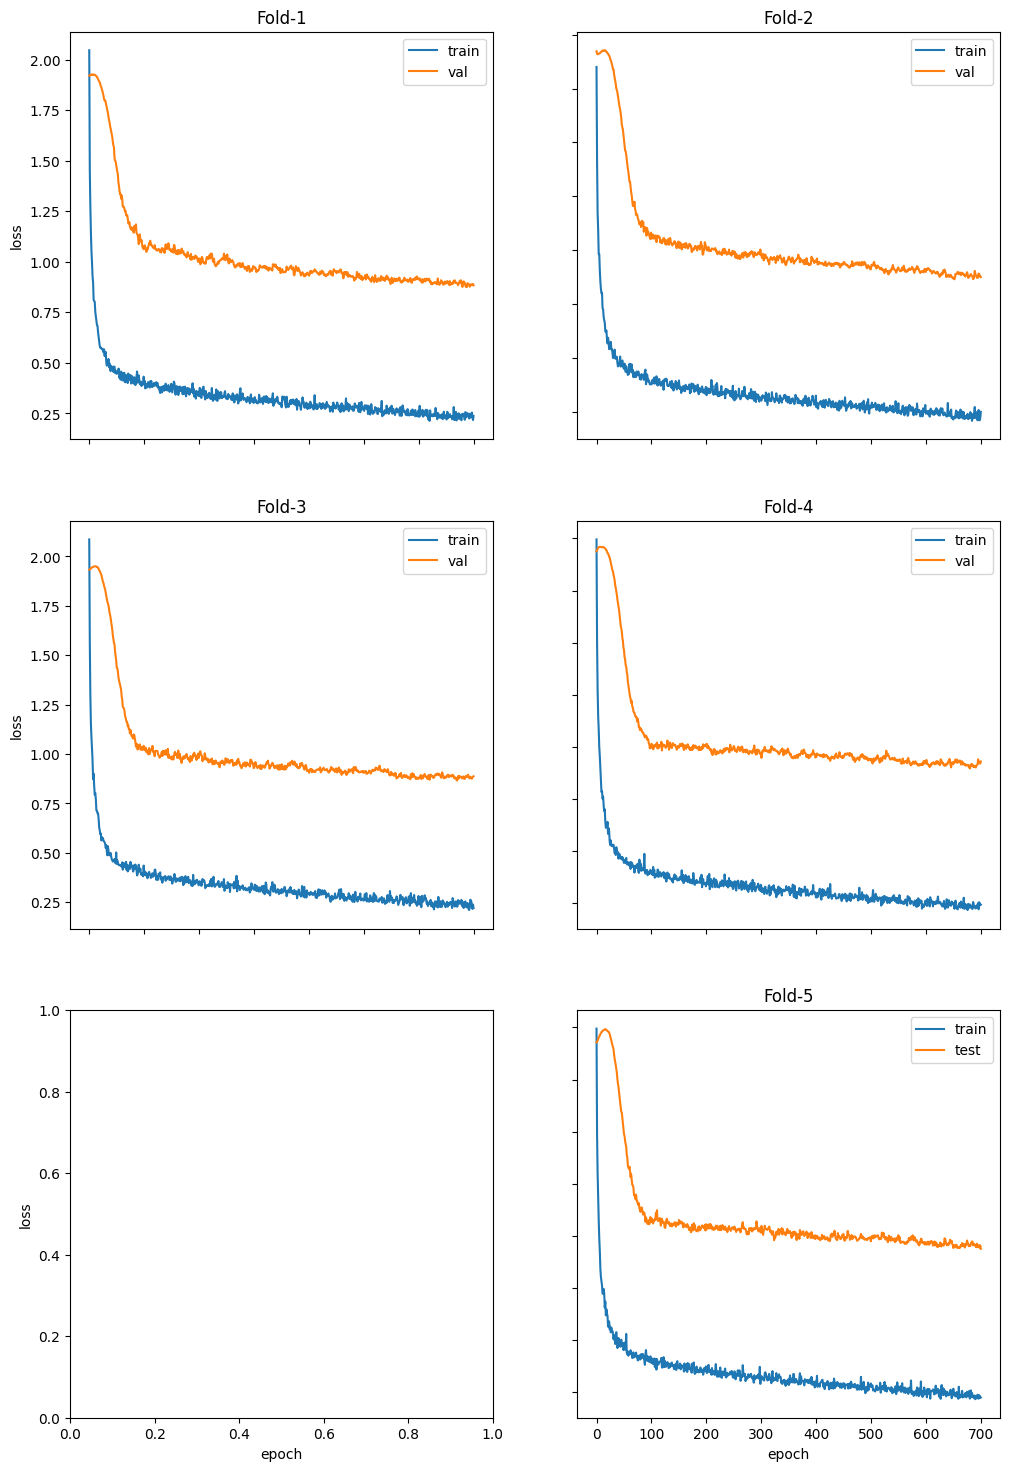

In [26]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(3, 2,figsize=(12,18))
axs[0, 0].plot(hist[0].history['loss'])
axs[0, 0].plot(hist[0].history['val_loss'])
axs[0, 0].set_title('Fold-1')
axs[0, 0].legend(['train', 'val'], loc='upper right')

axs[0, 1].plot(hist[1].history['loss'])
axs[0, 1].plot(hist[1].history['val_loss'])
axs[0, 1].set_title('Fold-2')
axs[0, 1].legend(['train', 'val'], loc='upper right')

axs[1, 0].plot(hist[2].history['loss'])
axs[1, 0].plot(hist[2].history['val_loss'])
axs[1, 0].set_title('Fold-3')
axs[1, 0].legend(['train', 'val'], loc='upper right')

axs[1, 1].plot(hist[3].history['loss'])
axs[1, 1].plot(hist[3].history['val_loss'])
axs[1, 1].set_title('Fold-4')
axs[1, 1].legend(['train', 'val'], loc='upper right')

axs[2, 1].plot(hist[4].history['loss'])
axs[2, 1].plot(hist[4].history['val_loss'])
axs[2, 1].set_title('Fold-5')
axs[2, 1].legend(['train', 'test'], loc='upper right')

for ax in axs.flat:
    ax.set(xlabel='epoch', ylabel='loss')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()
fig.savefig('emodbFemale_4Folds_65.png')

In [1]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix

savedir = 'emodb_gender_female_193'
num_folds = 5 
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

for i in range(num_folds):
    model_name = f"Model_{i}"

    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")

    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    print(f"Fold {i}: Accuracy = {acc:.2f}%")

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)
mean_acc = np.mean(accuracies)

print("\nMean Accuracy: %.2f%%" % mean_acc)
print("SD Accuracy: %.2f" % np.std(accuracies))

n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
ci_low = mean_acc - ci95
ci_high = mean_acc + ci95
print(f"95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]")


2025-11-10 14:55:03.781742: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 14:55:03.811014: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-10 14:55:04.484889: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-

Fold 0: Accuracy = 85.25%
Fold 1: Accuracy = 81.97%
Fold 2: Accuracy = 85.25%
Fold 3: Accuracy = 81.97%
Fold 4: Accuracy = 83.61%

Mean Accuracy: 83.61%
SD Accuracy: 1.47
95% CI: [82.32%, 84.89%]


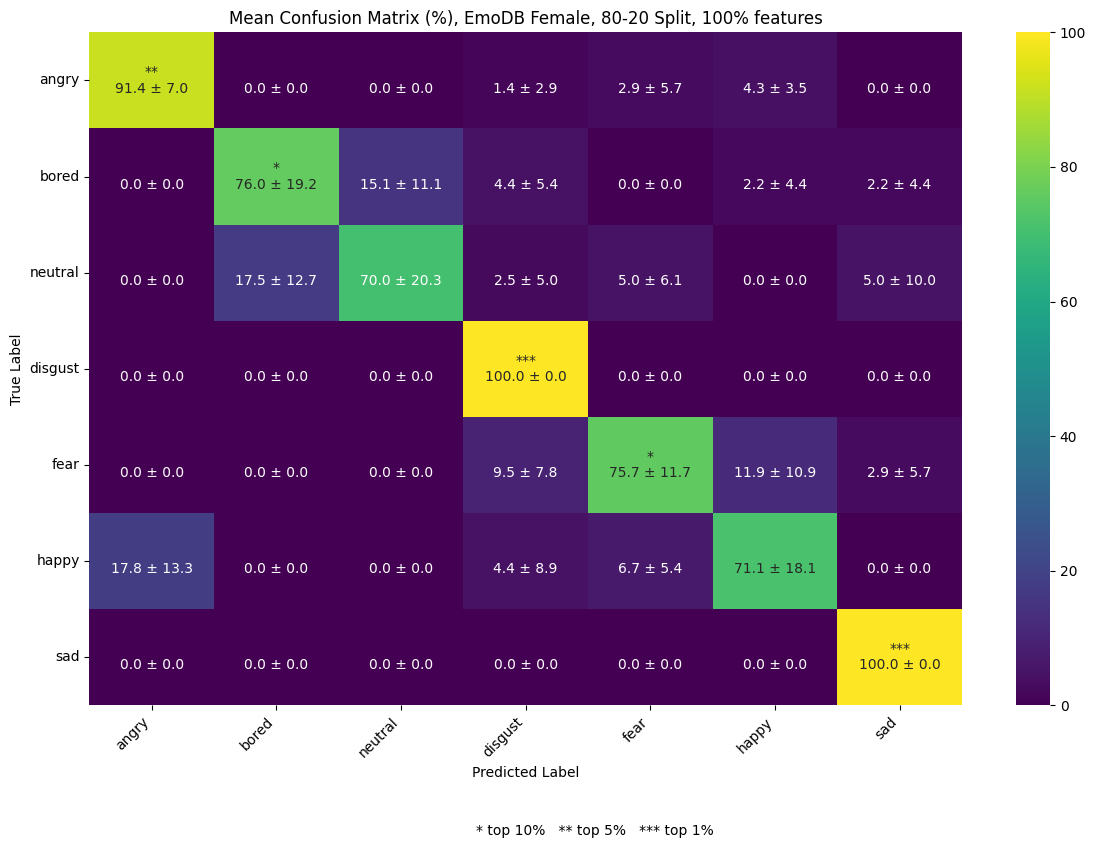

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100
np.save('cm_emodb_gender_female_193.npy', conf_matrices_percent)


mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

# Compute percentile thresholds for annotation
flat_vals = mean_cm.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

# Create annotation labels with significance symbols
labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        val = mean_cm[i, j]
        symbol = ""
        if val >= thr_99:
            symbol = "***"
        elif val >= thr_95:
            symbol = "**"
        elif val >= thr_90:
            symbol = "*"
        labels[i, j] = f"{symbol}\n{val:.1f} ± {std_cm[i, j]:.1f}"

listik = ['angry', 'bored', 'neutral', 'disgust', 'fear', 'happy', 'sad']

# Plot
plt.figure(figsize=(12,8))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)

ax.set_xticks(np.arange(len(listik)) + 0.5)
ax.set_yticks(np.arange(len(listik)) + 0.5)
ax.set_xticklabels(listik, rotation=45, ha="right")
ax.set_yticklabels(listik, rotation=0)

plt.title("Mean Confusion Matrix (%), EmoDB Female, 80-20 Split, 100% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.figtext(0.5, -0.05,
            "* top 10%   ** top 5%   *** top 1%",
            ha="center", fontsize=10)
plt.show()
